<a href="https://colab.research.google.com/github/Neuer2718/chicago-air-quality-analysis/blob/main/chicago_aqi_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import core data and scientific libraries
import pandas as pd          # data manipulation and analysis
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # plotting
import seaborn as sns        # statistical data visualization
from dataclasses import dataclass  # for creating simple data classes
from scipy import stats      # statistical tests and functions

# Set a consistent visual style for all plots
sns.set_theme(style="whitegrid")

# Configure default figure size and resolution for plots
plt.rcParams["figure.figsize"] = (10, 5)   # width, height in inches
plt.rcParams["figure.dpi"] = 120           # dots per inch (image resolution)

In [ ]:
# Load the Chicago air pollution data from a CSV file
# Make sure "chicago_air_pollution.csv" is in the same folder as this notebook
df = pd.read_csv("chicago_air_pollution.csv")

# Preview the first few rows to verify that the data loaded correctly
df.head()

,Unnamed: 0,city,tmpd,dptp,date,pm25tmean2,pm10tmean2,o3tmean2,no2tmean2
0,0,chic,31.5,31.500,1987-01-01,NaN,34.000000,4.250000,19.988095
1,1,chic,33.0,29.875,1987-01-02,NaN,NaN,3.304348,23.190994
2,2,chic,33.0,27.375,1987-01-03,NaN,34.166667,3.333333,23.815476
3,3,chic,29.0,28.625,1987-01-04,NaN,47.000000,4.375000,30.434524
4,4,chic,32.0,28.875,1987-01-05,NaN,NaN,4.750000,30.333333


In [ ]:
# Check the basic shape of the dataset: (rows, columns)
print(df.shape)

# List all column names to see what variables are available
print(df.columns)

# Print a concise summary: column types, non-null counts, memory usage
print(df.info())

# Count missing (NaN) values in each column
print(df.isnull().sum())

(6940, 9)
Index(['Unnamed: 0', 'city', 'tmpd', 'dptp', 'date', 'pm25tmean2',
       'pm10tmean2', 'o3tmean2', 'no2tmean2'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6940 entries, 0 to 6939
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6940 non-null   int64  
 1   city        6940 non-null   object 
 2   tmpd        6939 non-null   float64
 3   dptp        6938 non-null   float64
 4   date        6940 non-null   object 
 5   pm25tmean2  2493 non-null   float64
 6   pm10tmean2  6698 non-null   float64
 7   o3tmean2    6940 non-null   float64
 8   no2tmean2   6940 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 488.1+ KB
None
Unnamed: 0       0
city             0
tmpd             1
dptp             2
date             0
pm25tmean2    4447
pm10tmean2     242
o3tmean2         0
no2tmean2        0
dtype: int64


In [ ]:
from dataclasses import dataclass
import pandas as pd


@dataclass
class PollutionAnalyzer:
    # Store the full pollution DataFrame inside the analyzer
    df: pd.DataFrame

    def clean_data(self):
        """
        Make a cleaned version of the data:
        - copy the original dataframe
        - parse dates
        - filter to Chicago
        - add year / month / season columns
        """
        # Work on a copy so we don't modify the original df outside the class
        self.df = self.df.copy()

        # Convert the 'date' column to a proper datetime type
        self.df["date"] = pd.to_datetime(self.df["date"])

        # Keep only rows where 'city' looks like Chicago (case‑insensitive)
        self.df = self.df[self.df["city"].str.contains("chic", case=False, na=False)]

        # Create year and month columns for grouping and plotting
        self.df["year"] = self.df["date"].dt.year
        self.df["month"] = self.df["date"].dt.month

        # Map month numbers to seasons (Winter, Spring, Summer, Fall)
        self.df["season"] = self.df["month"].map({
            12: "Winter", 1: "Winter", 2: "Winter",
            3: "Spring", 4: "Spring", 5: "Spring",
            6: "Summer", 7: "Summer", 8: "Summer",
            9: "Fall", 10: "Fall", 11: "Fall"
        })

        # Return the cleaned DataFrame so it can be used outside the class
        return self.df

    def summary_stats(self):
        """
        Return basic descriptive statistics for weather and pollutant columns.
        """
        cols = ["tmpd", "dptp", "pm25tmean2", "pm10tmean2", "o3tmean2", "no2tmean2"]
        return self.df[cols].describe()

    def yearly_means(self):
        """
        Compute the average pollutant level for each year.
        """
        cols = ["pm25tmean2", "pm10tmean2", "o3tmean2", "no2tmean2"]
        return self.df.groupby("year")[cols].mean()

    def seasonal_means(self):
        """
        Compute the average pollutant level for each season.
        """
        cols = ["pm25tmean2", "pm10tmean2", "o3tmean2", "no2tmean2"]
        return self.df.groupby("season")[cols].mean()

    def correlation_table(self):
        """
        Return the correlation matrix for temperature, dew point,
        and all pollutant variables.
        """
        cols = ["tmpd", "dptp", "pm25tmean2", "pm10tmean2", "o3tmean2", "no2tmean2"]
        return self.df[cols].corr()


# Create an analyzer object using the raw dataframe
analyzer = PollutionAnalyzer(df)

# Run the cleaning step and save the cleaned DataFrame
df_clean = analyzer.clean_data()

# Preview the cleaned data
df_clean.head()

,Unnamed: 0,city,tmpd,dptp,date,pm25tmean2,pm10tmean2,o3tmean2,no2tmean2,year,month,season
0,0,chic,31.5,31.500,1987-01-01,NaN,34.000000,4.250000,19.988095,1987,1,Winter
1,1,chic,33.0,29.875,1987-01-02,NaN,NaN,3.304348,23.190994,1987,1,Winter
2,2,chic,33.0,27.375,1987-01-03,NaN,34.166667,3.333333,23.815476,1987,1,Winter
3,3,chic,29.0,28.625,1987-01-04,NaN,47.000000,4.375000,30.434524,1987,1,Winter
4,4,chic,32.0,28.875,1987-01-05,NaN,NaN,4.750000,30.333333,1987,1,Winter


In [ ]:
# Show descriptive statistics for temperature, dew point, and pollutants
analyzer.summary_stats()

,tmpd,dptp,pm25tmean2,pm10tmean2,o3tmean2,no2tmean2
count,6939.000000,6938.000000,2493.000000,6698.000000,6940.000000,6940.000000
mean,50.309339,40.341686,16.230958,33.895206,19.435513,25.231882
std,19.412801,18.487240,8.697750,17.967363,11.385984,7.991389
min,-16.000000,-25.625000,1.700000,2.000000,0.152778,6.158333
25%,35.000000,27.000000,9.700000,21.500000,10.072917,19.653819
50%,51.000000,39.875000,14.657143,30.278846,18.521802,24.555556
75%,67.000000,55.750000,20.600000,42.000000,27.000996,30.139040
max,92.000000,78.250000,61.500000,365.000000,66.587500,62.479984


In [ ]:
# Compute the average pollutant levels for each year
yearly_avg = analyzer.yearly_means()

# Display the yearly averages table
yearly_avg

,pm25tmean2,pm10tmean2,o3tmean2,no2tmean2
year,,,,
1987,NaN,40.307343,20.496564,25.291393
1988,NaN,43.243488,22.245075,25.341936
1989,NaN,40.285313,20.813772,27.364873
1990,NaN,35.495279,19.729815,23.056527
1991,NaN,36.876955,20.008401,21.916414
1992,NaN,38.816341,16.055857,25.858260
1993,NaN,36.465977,15.801949,26.131327
1994,NaN,40.079808,17.323548,29.102323
1995,NaN,35.617449,18.138648,27.946714


In [ ]:
# Compute the average pollutant levels for each season
seasonal_avg = analyzer.seasonal_means()

# Display the seasonal averages table
seasonal_avg

,pm25tmean2,pm10tmean2,o3tmean2,no2tmean2
season,,,,
Fall,15.096328,33.263295,14.475420,24.766554
Spring,15.036806,33.996260,23.668199,25.911952
Summer,16.456633,38.372379,29.493433,24.196573
Winter,18.463546,29.833114,9.870510,26.063084


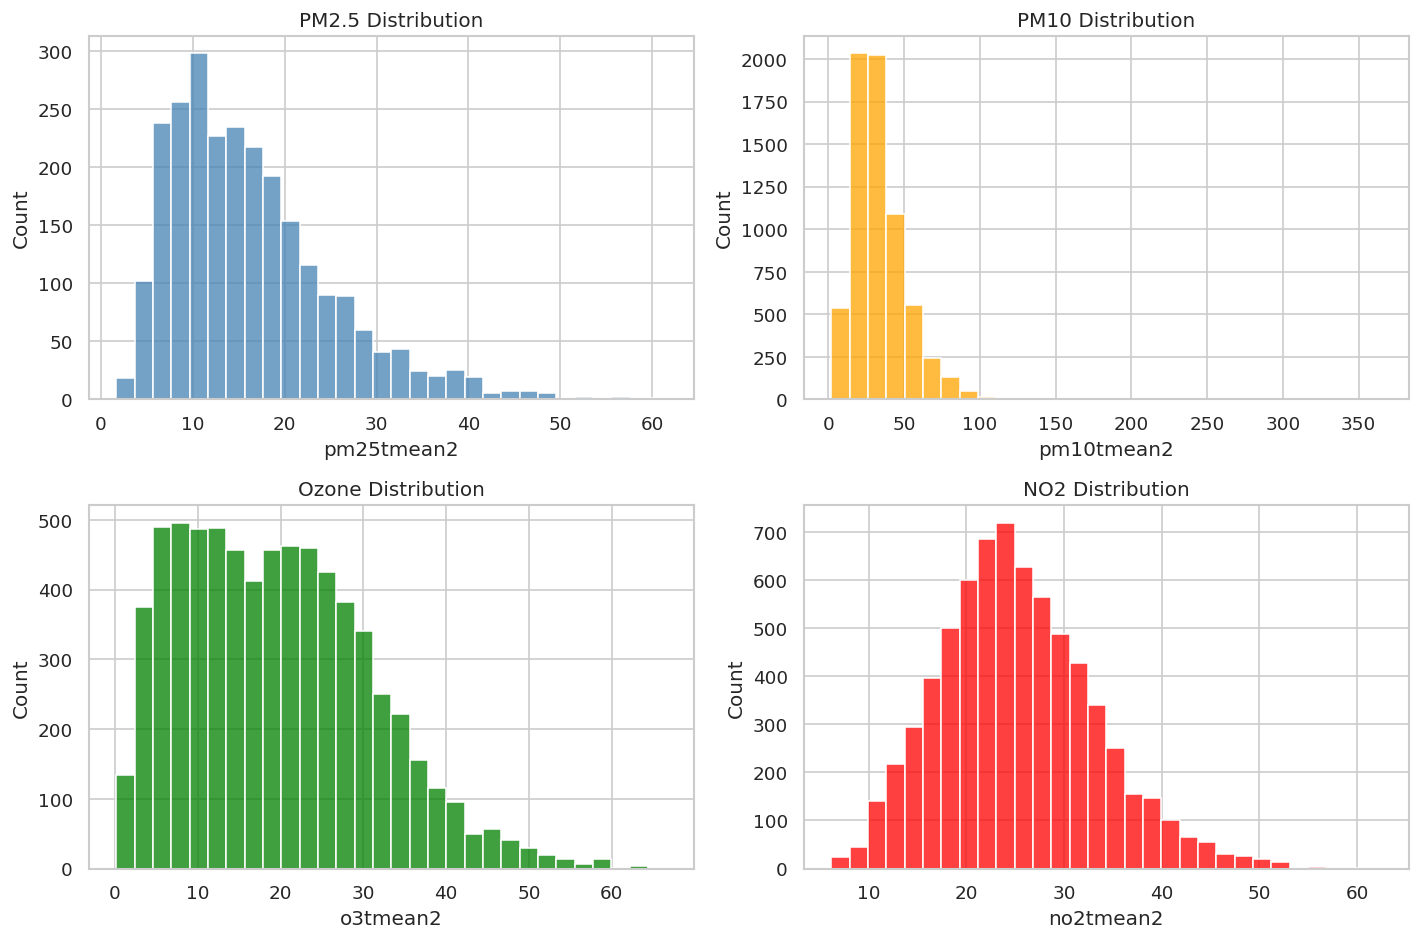

In [ ]:
# Create a 2x2 grid of subplots for the four histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram of PM2.5 values
sns.histplot(df_clean["pm25tmean2"].dropna(), bins=30, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("PM2.5 Distribution")

# Histogram of PM10 values
sns.histplot(df_clean["pm10tmean2"].dropna(), bins=30, ax=axes[0, 1], color="orange")
axes[0, 1].set_title("PM10 Distribution")

# Histogram of ozone values
sns.histplot(df_clean["o3tmean2"].dropna(), bins=30, ax=axes[1, 0], color="green")
axes[1, 0].set_title("Ozone Distribution")

# Histogram of NO2 values
sns.histplot(df_clean["no2tmean2"].dropna(), bins=30, ax=axes[1, 1], color="red")
axes[1, 1].set_title("NO2 Distribution")

# Adjust spacing so the plots don’t overlap
plt.tight_layout()

# Render the figure
plt.show()

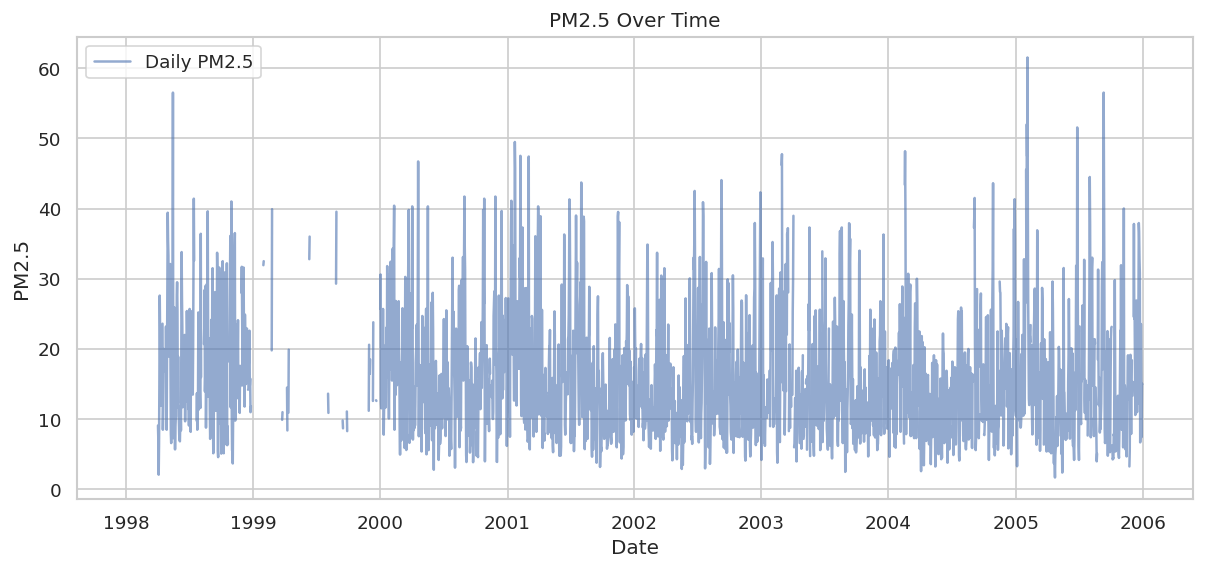

In [ ]:
# Line plot of daily PM2.5 values over time

# Create a new figure with a custom size
plt.figure(figsize=(12, 5))

# Plot PM2.5 against date; alpha controls transparency
plt.plot(df_clean["date"], df_clean["pm25tmean2"],
         alpha=0.6, label="Daily PM2.5")

# Add title and axis labels
plt.title("PM2.5 Over Time")
plt.xlabel("Date")
plt.ylabel("PM2.5")

# Show the legend (for the line label)
plt.legend()

# Render the plot
plt.show()

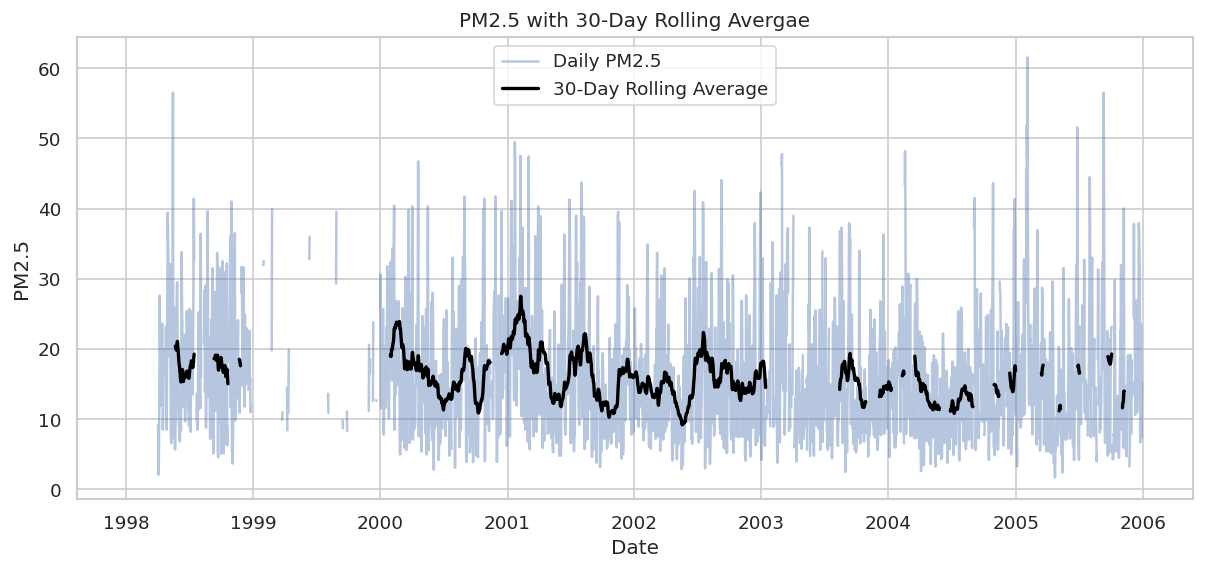

In [ ]:
# Sort the data by date so the rolling window is applied in time order
df_clean = df_clean.sort_values("date")

# Compute a 30-day rolling mean of PM2.5 to smooth short-term fluctuations
df_clean["pm25_30day"] = df_clean["pm25tmean2"].rolling(30).mean()

# Plot daily PM2.5 and the 30-day rolling average on the same figure
plt.figure(figsize=(12, 5))
plt.plot(df_clean["date"], df_clean["pm25tmean2"],
         alpha=0.4, label="Daily PM2.5")
plt.plot(df_clean["date"], df_clean["pm25_30day"],
         color="black", linewidth=2, label="30-Day Rolling Average")

# Add title and axis labels
plt.title("PM2.5 with 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("PM2.5")

# Show legend and render the plot
plt.legend()
plt.show()

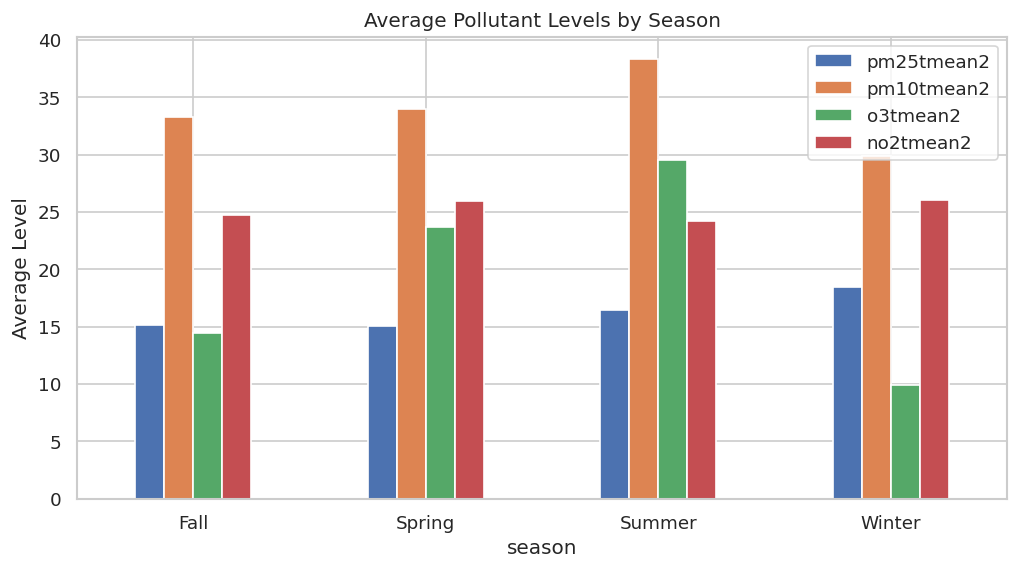

In [ ]:
# Bar chart of mean pollutant levels for each season
seasonal_avg.plot(kind="bar", figsize=(10, 5))

# Add title and axis label
plt.title("Average Pollutant Levels by Season")
plt.ylabel("Average Level")

# Keep season labels horizontal for readability
plt.xticks(rotation=0)

# Render the plot
plt.show()

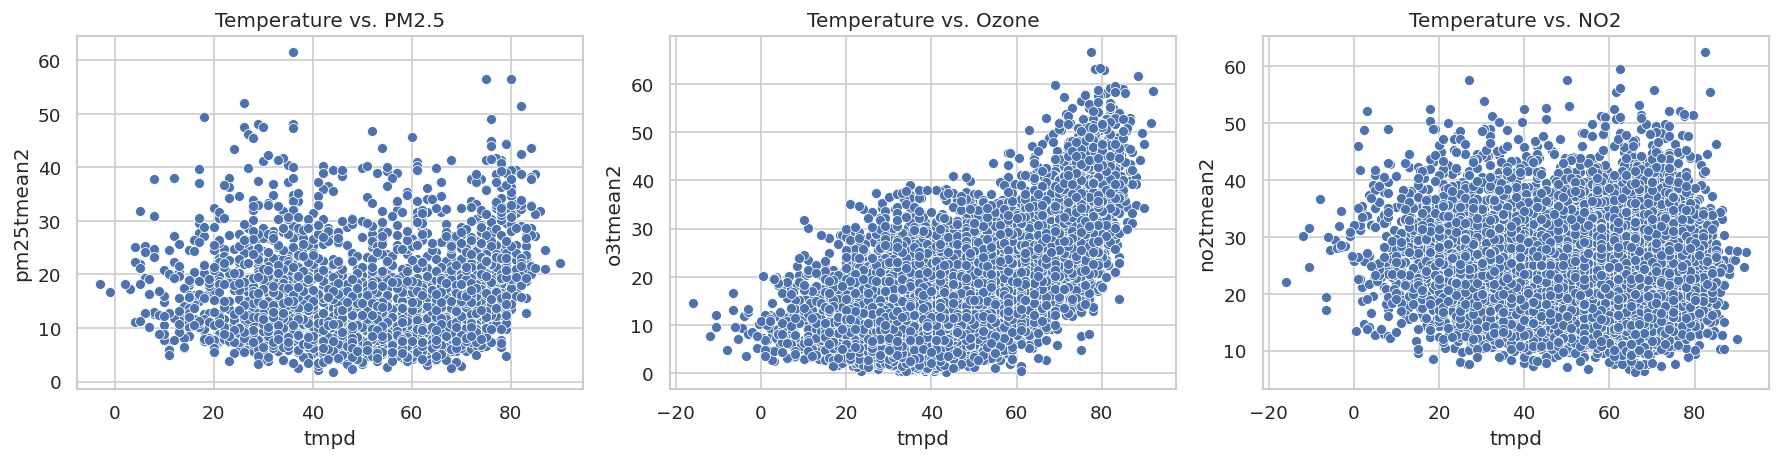

In [ ]:
# Scatterplots showing how each pollutant relates to temperature

# Create a row of 3 subplots (one for each pollutant)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Temperature vs PM2.5
sns.scatterplot(data=df_clean, x="tmpd", y="pm25tmean2", ax=axes[0])
axes[0].set_title("Temperature vs. PM2.5")

# Temperature vs Ozone
sns.scatterplot(data=df_clean, x="tmpd", y="o3tmean2", ax=axes[1])
axes[1].set_title("Temperature vs. Ozone")

# Temperature vs NO2
sns.scatterplot(data=df_clean, x="tmpd", y="no2tmean2", ax=axes[2])
axes[2].set_title("Temperature vs. NO2")

# Adjust spacing so subplots don't overlap and render the figure
plt.tight_layout()
plt.show()

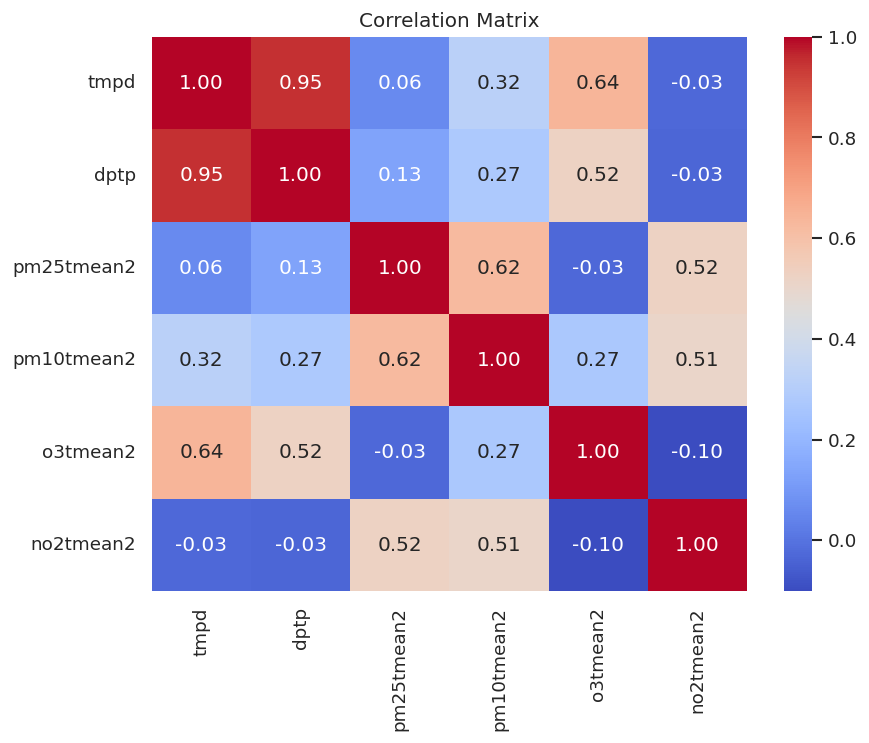

In [ ]:
# Compute the correlation matrix for temperature, dew point, and pollutants
corr = analyzer.correlation_table()

# Visualize the correlations as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

# Add a title and show the plot
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Compute Pearson correlation between temperature and each pollutant
for col in ["pm25tmean2", "pm10tmean2", "o3tmean2", "no2tmean2"]:
    # Keep only rows where both temperature and the pollutant are non-missing
    temp_df = df_clean[["tmpd", col]].dropna()

    # Calculate Pearson's r and the p-value for tmpd vs the current pollutant
    r, p = stats.pearsonr(temp_df["tmpd"], temp_df[col])

    # Print formatted correlation results
    print(f"Temperature vs {col}: r={r:.3f}, p={p:.4f}")

Temperature vs pm25tmean2: r=0.060, p=0.0027
Temperature vs pm10tmean2: r=0.320, p=0.0000
Temperature vs o3tmean2: r=0.639, p=0.0000
Temperature vs no2tmean2: r=-0.032, p=0.0080


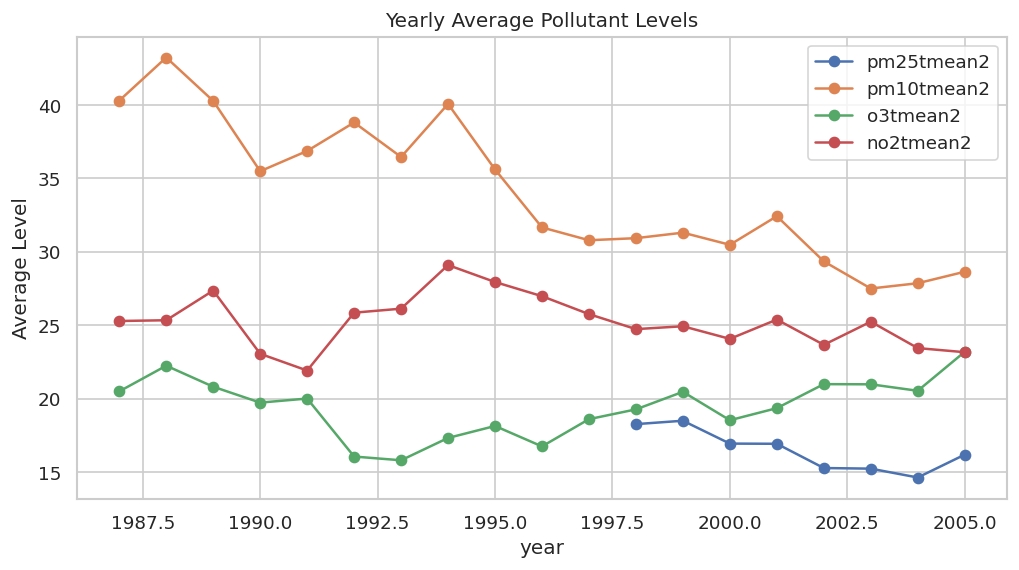

In [ ]:
# Line plot of yearly average levels for each pollutant
yearly_avg.plot(marker="o", figsize=(10, 5))

# Add a title and y-axis label
plt.title("Yearly Average Pollutant Levels")
plt.ylabel("Average Level")

# Render the plot
plt.show()

- Which pollutant had the highest variability?
  - PM10 shows the greatest variability: its histogram has the widest spread and its yearly averages range roughly from the low 40s down to the high 20s. NO2 is variable as well, but less than PM10.

- Did any pollutant show seasonal behavior?
  - PM10 is somewhat higher in summer than in other seasons, but the strongest seasonal behavior is in ozone. The seasonal bar chart shows ozone increasing from low values in winter to much higher averages in summer.

- Was temperature positively or negatively associated with ozone?
  - Temperature is strongly positively associated with ozone (r ≈ 0.64): higher temperatures generally correspond to higher ozone levels. The scatterplot suggests a nonlinear pattern where ozone increases more quickly at higher temperatures.

- Did air quality appear to improve or worsen over time?
  - PM10 clearly declined over the years, from yearly averages in the low 40s to the high 20s, indicating improvement for that pollutant. PM2.5 and NO2 also show a slight downward trend, while ozone fluctuates without a clear trend, so long‑term ozone changes are harder to judge from this simple analysis.